In [8]:
import os
import sys
import warnings

os.environ["PYTHONHASHSEED"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
sys.path.append(os.getcwd())
sys.path.append("..")
warnings.filterwarnings("ignore")

import re
import json
import numpy as np
from pathlib import Path
import glob
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from src.classification import load_dataset
from models.model import get_classifier

In [9]:
def _build_and_load_model(
    input_shape,
    num_classes: int,
    patch_sizes,
    model_type: str,
    units: int,
    seed: int,
    connectivity: float,
    leaky: float,
    spectral_radius: float,
    W_T: np.ndarray,
):
    model = get_classifier(
        input_shape=input_shape,
        num_classes=num_classes,
        patch_sizes=patch_sizes,
        model_type=model_type,
        units=units,
        connectivity=connectivity,
        leaky=leaky,
        spectral_radius=spectral_radius,
        seed=seed,
    )

    # build
    _ = model(tf.zeros((1,) + tuple(input_shape), dtype=tf.float32), training=False)

    # last Dense の kernel に W_T をセット
    # W_T shape: (D, K)
    model.layers[-1].set_weights([W_T.astype(np.float32)])

    return model


def make_red_overlay(
    img: np.ndarray,
    saliency: np.ndarray,
    top_pct: float = 0.2,
    alpha: float = 0.6,
    dim: float = 0.4,
) -> np.ndarray:
    """
    元画像を暗くし、上位 top_pct のsaliency領域を赤グラデーションで重ねる。

    Args:
        img:      (H, W, C) float32 [0,1]
        saliency: (H, W, C) or (H, W) logit drop map
        top_pct:  赤くする上位割合 (0.0~1.0)
        alpha:    赤の最大不透明度
        dim:      元画像の暗さ (0=真っ黒, 1=そのまま)

    Returns:
        (H, W, 3) float32 [0,1]
    """
    # saliency を 2D に
    s = saliency[:, :, 0] if saliency.ndim == 3 else saliency

    # 閾値: 上位 top_pct のみ赤にする
    threshold = np.percentile(s, 100 * (1 - top_pct))
    mask = np.clip((s - threshold) / (s.max() - threshold + 1e-8), 0, 1)  # 0~1 グラデーション

    # 元画像を暗くする (RGB化)
    base = (img[:, :, :3] if img.shape[-1] >= 3 else np.repeat(img, 3, axis=-1)) * dim

    # 赤チャンネルを重ねる
    red = np.zeros_like(base)
    red[:, :, 0] = mask

    out = base + alpha * red * mask[:, :, None]
    return np.clip(out, 0, 1).astype(np.float32)


def make_red_overlays(
    imgs: np.ndarray,
    maps: np.ndarray,
    fold: int = 0,
    top_pct: float = 0.2,
    alpha: float = 0.6,
    dim: float = 0.4,
) -> np.ndarray:
    """
    全クラス分の赤オーバーレイを一括生成。

    Args:
        imgs: (num_classes, H, W, C)
        maps: (num_classes, num_folds, H, W, C)
        fold: 使用する fold index
        top_pct, alpha, dim: make_red_overlay に渡すパラメータ

    Returns:
        (num_classes, H, W, 3)
    """
    return np.stack([
        make_red_overlay(imgs[k], maps[k, fold], top_pct=top_pct, alpha=alpha, dim=dim)
        for k in range(imgs.shape[0])
    ])


def show_red_overlays(
    imgs: np.ndarray,
    maps: np.ndarray,
    fold: int = 0,
    top_pct: float = 0.2,
    alpha: float = 0.6,
    dim: float = 0.4,
    classes: list[int] | None = None,
    ncols: int = 5,
    figsize: tuple[float, float] | None = None,
    title: str | None = None,
    save_path: str | None = None,
    dpi: int = 150,
):
    """
    赤オーバーレイをクラスごとに並べて表示。

    Args:
        imgs:    (num_classes, H, W, C)
        maps:    (num_classes, num_folds, H, W, C)
        fold:    表示する fold index
        top_pct: 上位何%を赤にするか (0.0~1.0)
        alpha:   赤の最大不透明度
        dim:     元画像の暗さ (0=真っ黒, 1=そのまま)
        classes: 表示するクラスのリスト (None で全クラス)
        ncols:   1行あたりの列数
        figsize: 図のサイズ (None で自動)
        title:   図全体のタイトル
        save_path: 指定時は画像を保存
        dpi:     保存時の解像度
    """
    classes = classes if classes is not None else list(range(imgs.shape[0]))
    overlays = make_red_overlays(imgs, maps, fold=fold, top_pct=top_pct, alpha=alpha, dim=dim)

    nrows = int(np.ceil(len(classes) / ncols))
    figsize = figsize or (2.8 * ncols, 2.8 * nrows + 0.4)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_2d(axes).ravel()

    for i, k in enumerate(classes):
        axes[i].imshow(overlays[k])
        axes[i].set_title(f"class {k}", fontsize=10)
        axes[i].axis("off")

    for i in range(len(classes), len(axes)):
        axes[i].axis("off")

    if title:
        fig.suptitle(title, fontsize=13)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()

In [10]:
ROOT_PATH = "/home/nakanishi/WORKSPACE/bidirectional_2D_reservoir_computing/results/nm2026"


def _infer_setting_from_dir(result_dir: str):
    name = Path(result_dir).name
    m = re.search(r"_(mnist|cifar_10|stl_10)_(esn|bi_esn|bi_esn2d)_units-(\d+)", name)
    if not m:
        raise ValueError(f"Cannot parse dataset/model/units from dir name: {name}")
    return m.group(1), m.group(2), int(m.group(3))


def _list_fold_dirs(result_dir: str):
    folds = sorted(
        Path(result_dir).glob("cv-*_seed-*"),
        key=lambda p: (int(p.name.split("_")[0].split("-")[1]), int(p.name.split("_")[1].split("-")[1])),
    )
    if not folds:
        raise FileNotFoundError(f"No fold dirs found under: {result_dir} (expected cv-*_seed-*)")
    return folds


def _load_fold_artifacts(fold_dir: Path):
    bp, mw = fold_dir / "best_param.json", fold_dir / "model_weights.npz"
    for f in (bp, mw):
        if not f.exists():
            raise FileNotFoundError(f"Missing {f.name}: {f}")
    best_param = json.loads(bp.read_text(encoding="utf-8"))
    return best_param.get("resolved_hyperparams", {}), best_param.get("fixed_defaults", {}), np.load(mw)["W_T"]


def _pick_test_images_per_class(x_test, y_test, index: int, num_classes: int = 10):
    imgs = []
    for k in range(num_classes):
        idxs = np.where(y_test == k)[0]
        if index >= len(idxs):
            raise IndexError(f"class {k}: only {len(idxs)} samples, index={index} out of range")
        imgs.append(x_test[idxs[index]])
    return np.stack(imgs)


@tf.function
def _logits(model, x):
    return model(x, training=False)


def _build_patch_coords(H, W, patch_h, patch_w):
    return [
        (y0, min(y0 + patch_h, H), x0, min(x0 + patch_w, W))
        for y0 in range(0, H, patch_h)
        for x0 in range(0, W, patch_w)
    ]


def _build_occluded_batch(img, patches, fill):
    occluded = np.tile(img, (len(patches), 1, 1, 1))
    for i, (y0, y1, x0, x1) in enumerate(patches):
        occluded[i, y0:y1, x0:x1] = fill[y0:y1, x0:x1]
    return occluded


def _batch_inference(model, images, batch_size=128):
    results = []
    for start in range(0, len(images), batch_size):
        batch = tf.constant(images[start : start + batch_size], dtype=tf.float32)
        results.append(_logits(model, batch).numpy())
    return np.concatenate(results, axis=0)


def _occlusion_maps_for_fold(model, imgs, num_classes, patches, fill, batch_size=128):
    """
    Returns:
        maps:   (num_classes, H, W, C) オクルージョンマップ
        preds:  (num_classes,) 各クラス画像に対する予測ラベル
    """
    H, W, C = imgs.shape[1:]

    # 全クラスのベースlogitを1回の推論で取得 (num_classes, num_classes)
    base_logits = _logits(model, tf.constant(imgs, dtype=tf.float32)).numpy()
    preds = base_logits.argmax(axis=1)  # (num_classes,)

    maps = np.zeros((num_classes, H, W, C), dtype=np.float32)

    for k in range(num_classes):
        occluded = _build_occluded_batch(imgs[k], patches, fill)
        occl_logits = _batch_inference(model, occluded, batch_size=batch_size)

        score = np.zeros((H, W), dtype=np.float32)
        base_k = base_logits[k, k]
        for i, (y0, y1, x0, x1) in enumerate(patches):
            score[y0:y1, x0:x1] = base_k - occl_logits[i, k]

        maps[k] = np.repeat(score[..., None], C, axis=-1)

    return maps, preds


def get_occlusion_maps(
    result_dir: str,
    index: int = 1,
    baseline: str = "zero",
    use_patch_size: bool = True,
    patch_h: int | None = None,
    patch_w: int | None = None,
    batch_size: int = 128,
):
    """
    Returns:
        imgs:   (10, H, W, C)
        maps:   (10, num_folds, H, W, C)
        preds:  (10, num_folds)  各fold-seedでの予測ラベル
    """
    dataset, model_type, units = _infer_setting_from_dir(result_dir)
    _, _, x_test, y_test, num_classes = load_dataset(dataset)
    imgs = _pick_test_images_per_class(x_test, y_test, index=index)

    if imgs.max() > 1.5:
        imgs, x_test = imgs.astype(np.float32) / 255.0, x_test.astype(np.float32) / 255.0
    else:
        imgs = imgs.astype(np.float32)

    H, W, C = imgs.shape[1:]
    folds = _list_fold_dirs(result_dir)

    if baseline == "mean":
        fill = x_test.mean(axis=0).astype(np.float32)
    elif baseline == "zero":
        fill = np.zeros((H, W, C), dtype=np.float32)
    else:
        raise ValueError(f"baseline must be 'zero' or 'mean', got {baseline}")

    maps = np.zeros((num_classes, len(folds), H, W, C), dtype=np.float32)
    preds = np.zeros((num_classes, len(folds)), dtype=np.int32)

    for j, fold_dir in enumerate(folds):
        hp, fixed, W_T = _load_fold_artifacts(fold_dir)

        def _g(key, default):
            return float(hp.get(key, fixed.get(key, default)))

        ph = int(fixed.get("patch_h", 4)) if use_patch_size else int(patch_h or fixed.get("patch_h", 4))
        pw = int(fixed.get("patch_w", 4)) if use_patch_size else int(patch_w or fixed.get("patch_w", 4))

        model = _build_and_load_model(
            input_shape=(H, W, C),
            num_classes=num_classes,
            patch_sizes=(ph, pw),
            model_type=model_type,
            units=units,
            seed=int(fold_dir.name.split("_")[1].split("-")[1]),
            connectivity=_g("connectivity", 0.1),
            leaky=_g("leaky", 0.9),
            spectral_radius=_g("spectral_radius", 0.95),
            W_T=W_T,
        )

        patches = _build_patch_coords(H, W, ph, pw)
        fold_maps, fold_preds = _occlusion_maps_for_fold(
            model, imgs, num_classes, patches, fill, batch_size=batch_size
        )

        for k in range(num_classes):
            maps[k, j] = fold_maps[k]
        preds[:, j] = fold_preds

        tf.keras.backend.clear_session()

    return imgs, maps, preds


def _find_latest_experiment_dir(dataset, model, units, root_path=ROOT_PATH):
    pattern = str(Path(root_path) / "**" / f"*_{dataset.lower()}_{model.lower()}_units-{int(units)}")
    candidates = sorted(
        (p for p in glob.glob(pattern, recursive=True) if Path(p).is_dir()),
        key=lambda p: (re.match(r"(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})_", Path(p).name) or ["", ""])[1],
    )
    if not candidates:
        raise FileNotFoundError(f"No experiment dir matched: {pattern}")
    return candidates[-1]


def get_occlusion_maps_by_setting(
    setting: tuple[str, str, int],
    index: int = 1,
    baseline: str = "zero",
    use_patch_size: bool = True,
    patch_h: int | None = None,
    patch_w: int | None = None,
    root_path: str = ROOT_PATH,
    batch_size: int = 128,
):
    dataset, model, units = setting
    result_dir = _find_latest_experiment_dir(dataset, model, int(units), root_path=root_path)
    return get_occlusion_maps(
        result_dir=result_dir,
        index=index,
        baseline=baseline,
        use_patch_size=use_patch_size,
        patch_h=patch_h,
        patch_w=patch_w,
        batch_size=batch_size,
    )

In [11]:
# ====== 実行例 ======
# result_dir と index を指定して実行
index = 1

esn_imgs, esn_maps, esn_preds = get_occlusion_maps_by_setting(setting=("mnist", "esn", 128), index=index)
biesn_imgs, biesn_maps, biesn_preds = get_occlusion_maps_by_setting(setting=("mnist", "bi_esn", 128), index=index)
biesn2d_imgs, biesn2d_maps, biesn2d_preds = get_occlusion_maps_by_setting(setting=("mnist", "bi_esn2d", 256), index=index)

In [12]:
for i in range(10):
    print(f"Class {i}: ESN pred={esn_preds[i]}, Bi-ESN pred={biesn_preds[i]}, Bi-2D-ESN pred={biesn2d_preds[i]}")   

Class 0: ESN pred=[8 2 2 5 5 6 6 6 6 4 0 9 7 7 2], Bi-ESN pred=[3 4 5 4 8 9 6 6 6 5 8 5 2 0 2], Bi-2D-ESN pred=[6 7 6 6 6 8 2 8 9 0 0 5 6 3 2]
Class 1: ESN pred=[8 2 2 3 5 6 6 6 6 4 0 5 7 7 2], Bi-ESN pred=[3 4 5 4 8 1 6 6 6 5 1 5 2 0 3], Bi-2D-ESN pred=[6 7 6 6 2 8 1 8 9 1 0 5 5 3 7]
Class 2: ESN pred=[8 2 2 3 5 6 6 5 6 4 0 9 7 7 2], Bi-ESN pred=[3 4 5 4 8 9 6 6 6 7 8 5 2 0 4], Bi-2D-ESN pred=[6 7 0 6 6 8 2 9 9 1 0 5 6 3 7]
Class 3: ESN pred=[8 2 2 3 5 6 6 6 6 4 0 5 7 7 2], Bi-ESN pred=[3 4 3 4 8 1 6 6 6 5 1 5 2 0 2], Bi-2D-ESN pred=[3 7 6 6 2 8 1 9 9 1 0 5 9 3 7]
Class 4: ESN pred=[8 2 8 3 5 6 2 1 6 4 0 9 7 7 2], Bi-ESN pred=[3 4 5 4 8 9 6 5 6 5 8 7 2 0 3], Bi-2D-ESN pred=[3 7 5 6 6 8 4 9 9 0 0 5 6 3 7]
Class 5: ESN pred=[8 2 8 3 5 6 2 1 6 4 0 9 7 7 2], Bi-ESN pred=[3 4 5 4 8 9 6 6 6 7 8 7 2 0 3], Bi-2D-ESN pred=[6 7 5 6 2 8 2 9 9 0 0 3 8 3 7]
Class 6: ESN pred=[8 2 2 5 5 6 2 1 6 4 0 9 7 7 2], Bi-ESN pred=[3 4 3 4 8 9 4 6 6 5 8 5 2 0 3], Bi-2D-ESN pred=[6 7 6 6 6 8 1 8 9 0 0 3 2 3 7]

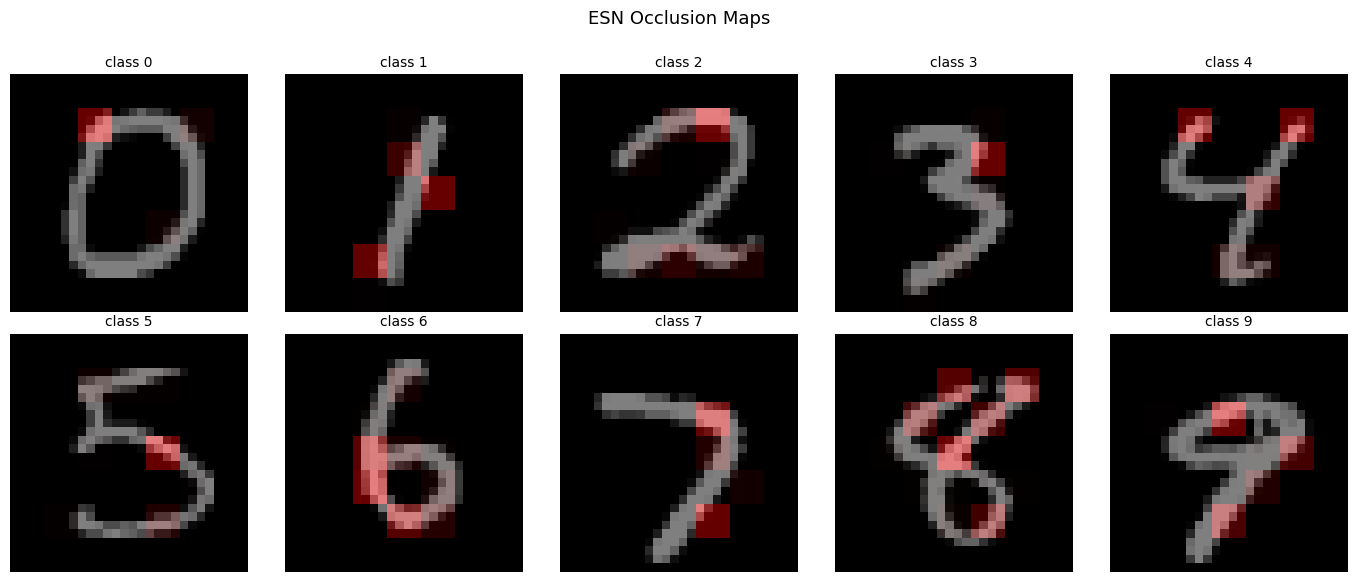

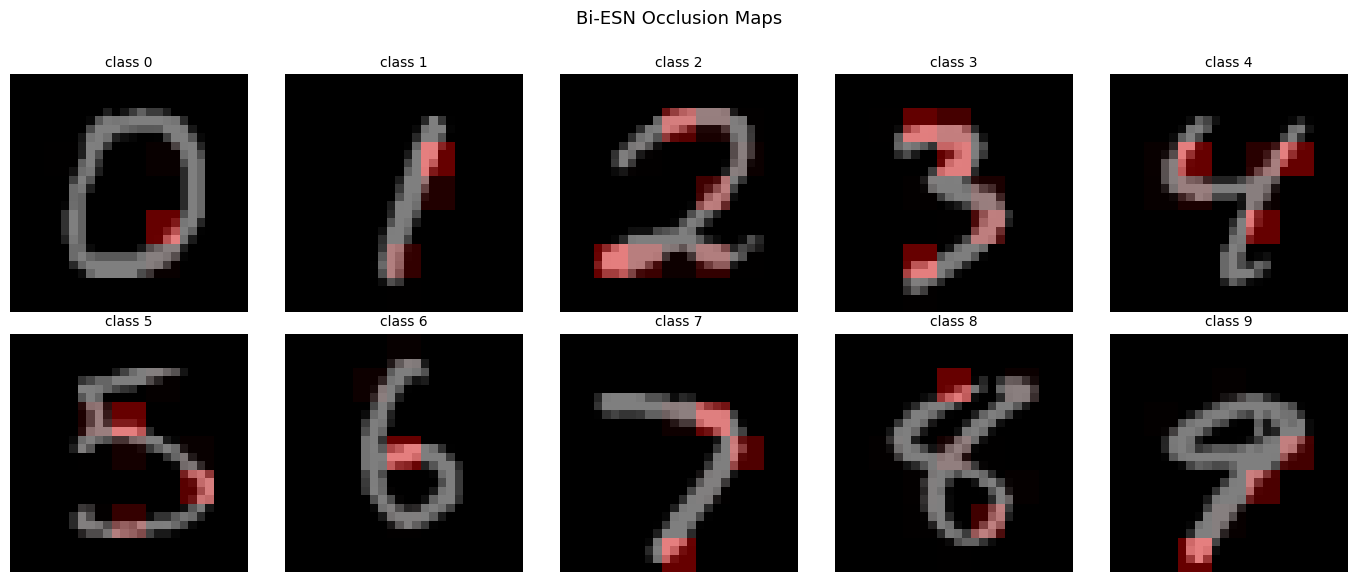

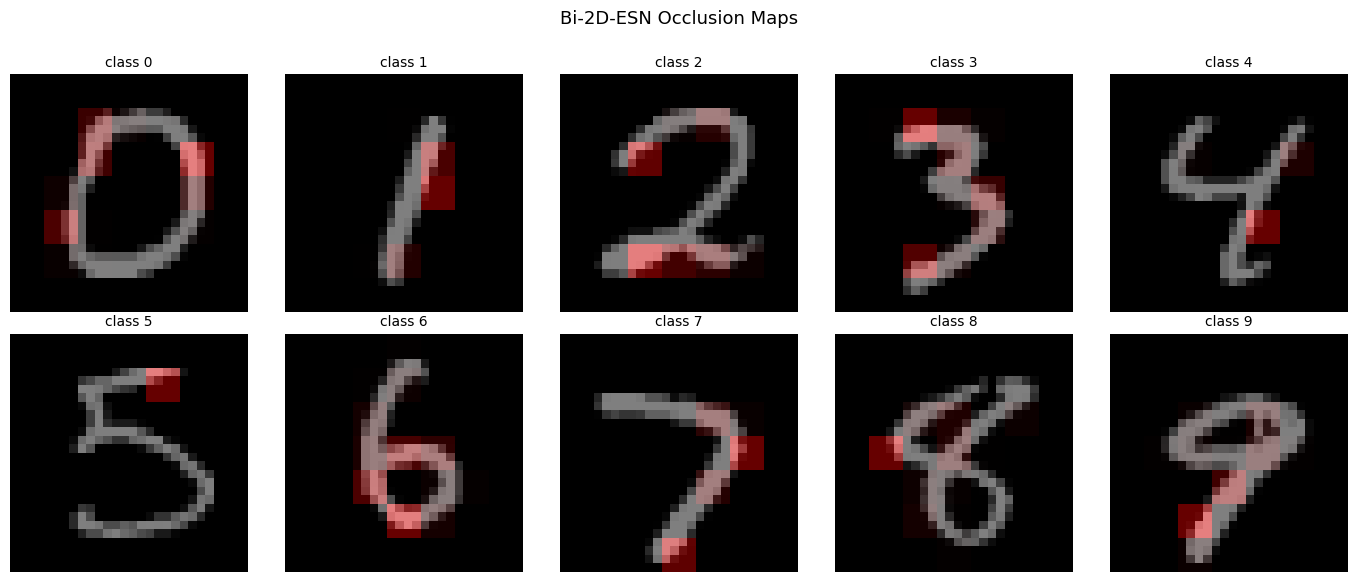

In [13]:
show_red_overlays(esn_imgs, esn_maps, fold=0, title="ESN Occlusion Maps", top_pct=0.3, dim=0.5, alpha=0.4)
show_red_overlays(biesn_imgs, biesn_maps, fold=0, title="Bi-ESN Occlusion Maps", top_pct=0.3, dim=0.5, alpha=0.4)
show_red_overlays(biesn2d_imgs, biesn2d_maps, fold=0, title="Bi-2D-ESN Occlusion Maps", top_pct=0.3, dim=0.5, alpha=0.4)